In [1]:
# This notebook demonstrates how to use ROSALIA to analyze stray light in a simple exposure. 
import rosalia as rs

# Let's define the minimum parameters to generate a dummy Roman / WFI image
# To get some challenging environment, let's target the Pleiades.
ra = 56.6583333  # Right ascension, in degrees. 
dec = +24.1780556 # Declination, in degrees.
PA = 0 # Position angle, in degrees.
from astropy.time import Time
date = Time("2026-12-01T00:00:00") # Date of the observation, in Astropy Time YYYY-MM-DDTHH:MM:SS format.
bandpass = "F129"
exptime = 600 # Exposure time, in seconds.


observer={"TELESCOP": "Roman/WFI", 
          "pointing": [ra, dec], 
          "FILTER":bandpass, 
          "PA_Y": PA, 
          "EXPSTART": 61192.00000, #  date.mjd, 
          "EXPTIME": exptime}

prefix = "Pleiades"
custom_roman_exposure = rs.core.exposure(observer=observer, prefix=prefix) 

> roman_wfi_exposure


2026-07-28T14:05:43.718106 > Fetching catalog


18it [00:05,  3.29it/s]

2026-07-28T14:05:50.003623 > Done.
2026-07-28T14:05:50.013319 > Starting Stray-light scan: 



100%|██████████| 18/18 [01:29<00:00,  4.96s/it]


2026-07-28T14:07:21.903769 > Done : 0:01:31.890482 elapsed.
 > Reconstructing the Stray-light / Main offender map: 
2026-07-28T14:07:24.074060 > Done : 


...

2026-07-28T14:07:26.374100 > Drizzling maps... 
















2026-07-28 14:08:32 WARNING  findfont: Failed to find font weight normal, now using 500.


2026-07-28T14:08:32.080461 > Done
2026-07-28T14:08:32.080643 > Summary plots... 
Plot: Stray-light surface brightness magnitude.
DEMO WARNING: make_stray_plot is Assuming F129.
SVO reported the transmission in m2. Correcting by area of the telescope (4.523893421169302 m2 )


2026-07-28 14:08:32 WARNING  findfont: Failed to find font weight normal, now using 500.


25
35


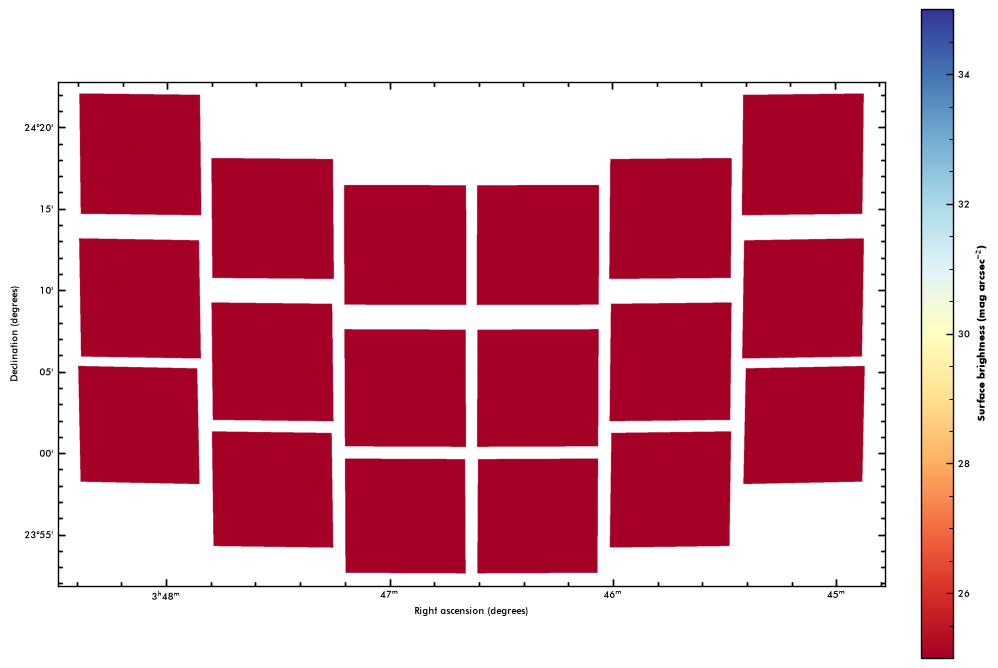

Plot: Stray-light surface brightness flux.
3775037.772015266
5334220.286731258


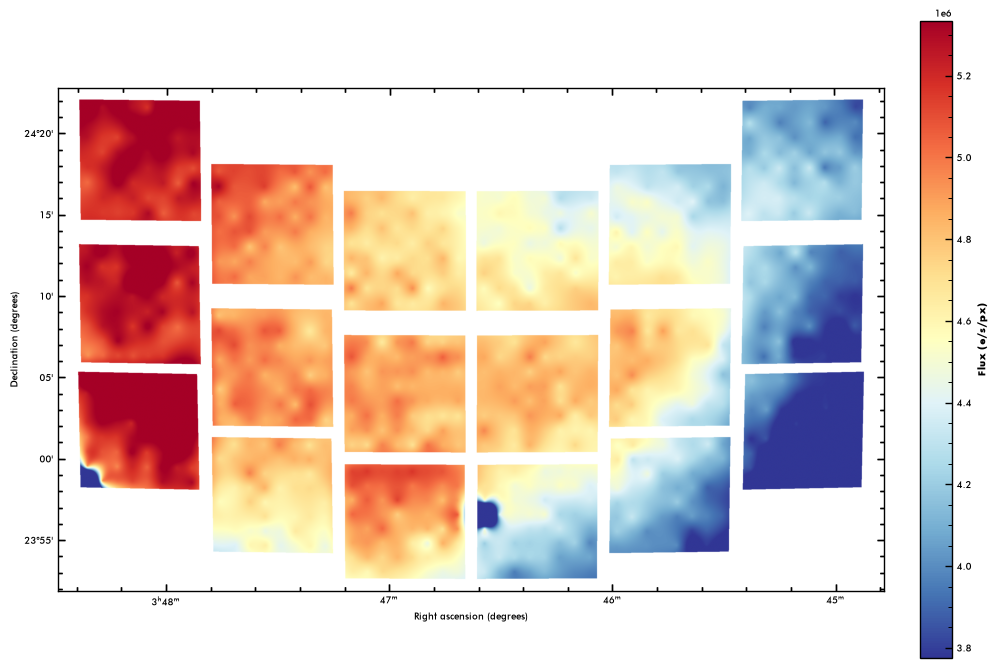

Plot: Main offender map.
1.0
1.0
Unique IDs:
[1]
Unique IDs with counts > 1:
[1]


2026-07-28 14:08:39 WARNING  findfont: Failed to find font weight normal, now using 500.


Simbad cannot find the name of the offender at 68.84425 - 21.92466
Main stray-light offenders:

100.00% - (68.84, 21.92), m=-27.03 - CAT_ID_1


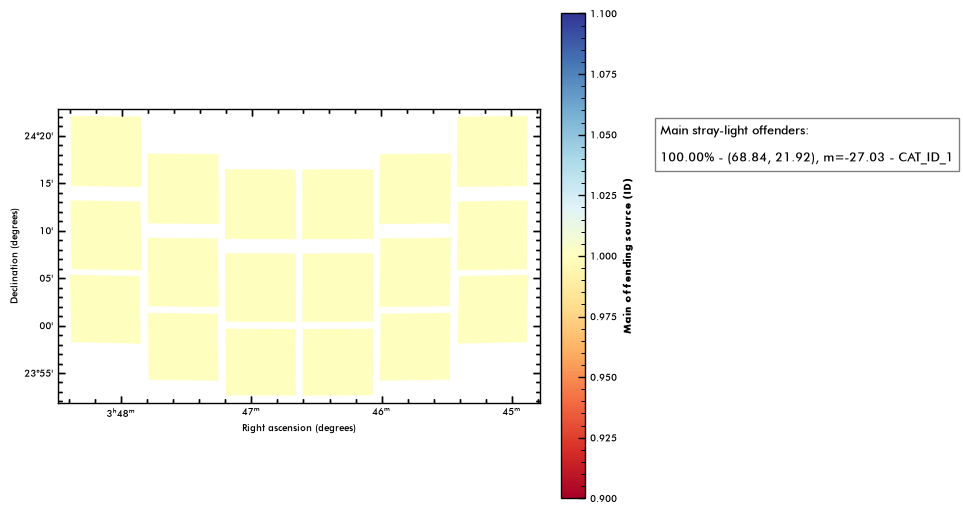

Plot: Source environment map.
SSO body: Sun not found. Skipping
SSO body: Moon not found. Skipping
SSO body: Earth not found. Skipping
SSO body: Mercury not found. Skipping
SSO body: Venus not found. Skipping
SSO body: Mars not found. Skipping
SSO body: Jupiter not found. Skipping
SSO body: Saturn not found. Skipping
SSO body: Uranus not found. Skipping
SSO body: Neptune not found. Skipping
SSO body: Pluto not found. Skipping


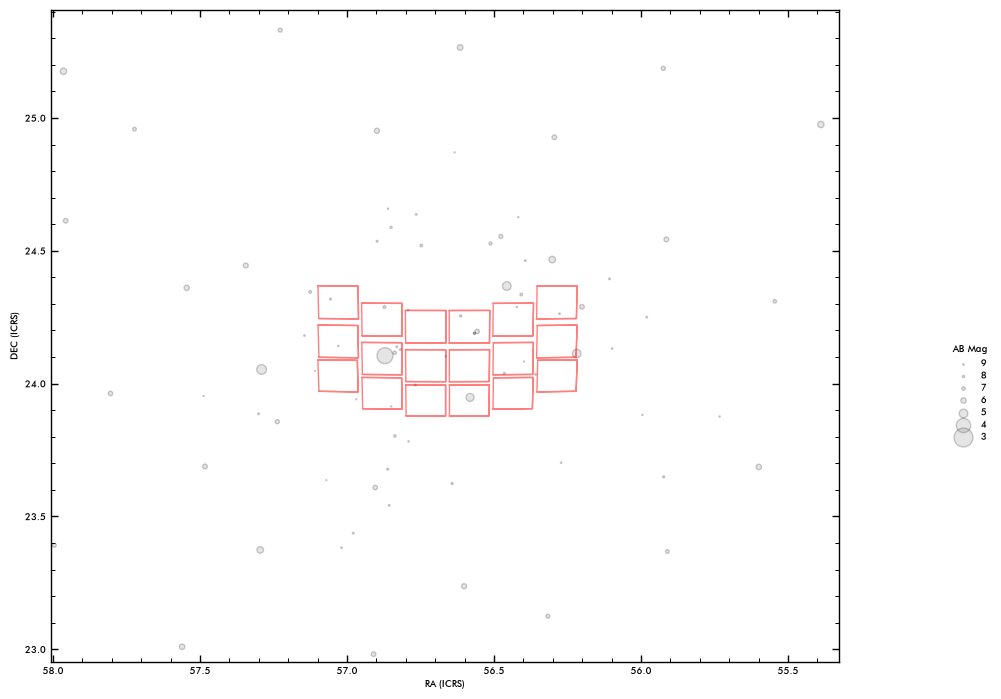

Plot: Location of Main offenders on NDI map.
Unique IDs:
[1]
Unique IDs with counts > 1:
[1]
Simbad cannot find the name of the offender at 68.84425 - 21.92466
Main stray-light offenders:

100.00% - (68.84, 21.92), m=-27.03 - CAT_ID_1
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN'
CUNIT : 'deg' 'deg'
CRVAL : 56.6583333 24.1780556
CRPIX : 636.5 636.5
NAXIS : 1273  1273


2026-07-28 14:08:42 WARNING  findfont: Failed to find font weight normal, now using 500.



127
/bin/sh: magick: command not found

2026-07-28T14:08:43.765618 > Done
Output saved in: /Users/aborlaff/NASA/ROSALIA/notebooks/tutorials/Pleiades_Roman_RA_056.658_DEC_024.178_MJD_61192.00000_PA_000.00_stray.fits
Report saved in: /Users/aborlaff/NASA/ROSALIA/notebooks/tutorials/Pleiades_Roman_RA_056.658_DEC_024.178_MJD_61192.00000_PA_000.00_stray.pdf


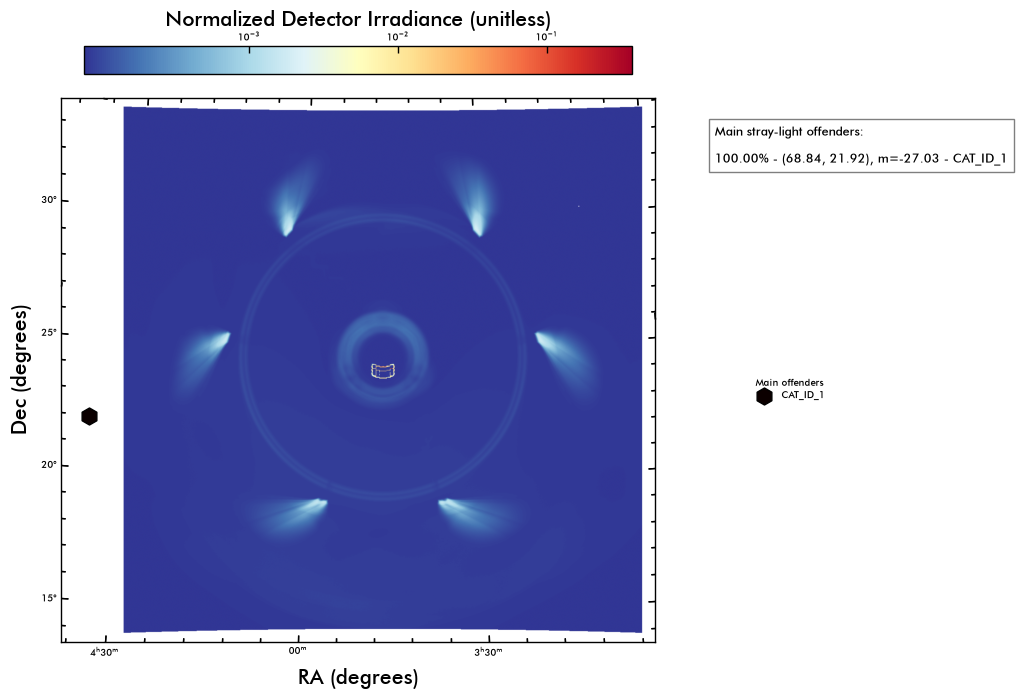

In [2]:
straylevel_all_SCAS = custom_roman_exposure.straylight(g_mag_max=15)

In [ ]:
# Benchmarking: 
# 1 - 8:30 min # Original 
# 2 - 6:45     # Using pickled Interpolators and pre calculated Rotators
# 3 - 6:30     # Pre calculating NDI conversion factor 
# 4 - 6:20     # Add all the straylight maps at the end 
# 5 - 3:45     # Parallel analysis per SCA 
# 6 - 3:35     # Parallel drizzling 
# 7 - 3:00     # Linear Interpolation instead of reprojecting.  